<a href="https://colab.research.google.com/github/IL0NKA/hotel_booking_sdk/blob/main/pr3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №2
**Тема:** РЕГРЕСІЯ

## Мета роботи
Закріпити основні поняття використання моделі лінійної регресії в машинному навчанні

Завдання:
•	Прочитайте файл .csv у DataFrame pandas.
•	Досліджуйте набір даних за допомогою бібліотек візуалізації Python.
•	Експериментуйте з різними ознаками для створення моделі лінійної регресії.
•	Налаштуйте гіперпараметри моделі.
•	Порівняйте результати навчання, використовуючи середню квадратичну помилку та графіки втрат.
•	Спробуйте побудувати модель та використати регресії для інших ознак та міток.



**Хід роботи**

Для виконання завдання будемо використовувати файл з даними, який доступный за посиланням: [City of Chicago Taxi Trips dataset](https://data.cityofchicago.org/Transportation/Taxi-Trips-2013-2023-/wrvz-psew/about_data)
В ньому розташовані дані про таксі Чикаго.

Перегляньте, яка інформація там є https://data.cityofchicago.org/Transportation/Taxi-Trips-2024-/ajtu-isnz/about_data


**Крок 1.** Імпортуйте необхідні бібліотеки

In [1]:
# Робота з даними
import pandas as pd
import numpy as np

# Візуалізація
import matplotlib.pyplot as plt
import seaborn as sns

# Моделювання
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


**Крок 2**. Завантажте дані з хмари

In [2]:
url = "https://data.cityofchicago.org/resource/wrvz-psew.csv?$limit=1000"  # приклад: беремо 1000 рядків
df = pd.read_csv(url)


print(df.shape)
df.head()

(1000, 23)


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,7c14379917299666678dc9257286799a91727da9,89a40bbeb44e22e8169b4ba823c5eee94b324219fbe8c0...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,300,0.70,NaN,NaN,28.0,28.0,...,2.0,7.00,Unknown,Taxi Affiliation Services,41.874005,-87.663518,POINT (-87.6635175498 41.874005383),41.874005,-87.663518,POINT (-87.6635175498 41.874005383)
1,5beed53a8f8bf37104223411fef93b1aa2df46e8,644680ecf5bbb5af6329b0c9d4595c39344cd6c50fabab...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,552,0.56,NaN,NaN,32.0,32.0,...,1.0,10.00,Credit Card,Sun Taxi,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.878866,-87.625192,POINT (-87.6251921424 41.8788655841)
2,716d7a0a2a097facc3f0f63e326830ecdf923d0a,2d72c5e6313ad93f663008a55045cad0c76164b057dcb7...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,649,2.57,1.703183e+10,1.703133e+10,28.0,33.0,...,1.0,12.50,Credit Card,City Service,41.885281,-87.657233,POINT (-87.6572331997 41.8852813201),41.859350,-87.617358,POINT (-87.6173580061 41.859349715)
3,1adedef3b9733f6a1859137ce37d8c685ad36cea,7d2e7cdd59237335e96b9b1a897a5e48cb4df467e6c092...,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,121,0.45,NaN,NaN,8.0,8.0,...,0.0,6.75,Credit Card,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
4,d51430f93404726b121d82d42efc29a2062895a8,24d4c5e51d147aecbb7c4a1ad70c38dbc05c7b4485f6de...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,379,1.25,NaN,NaN,14.0,13.0,...,0.0,10.25,Credit Card,Taxicab Insurance Agency Llc,41.968069,-87.721559,POINT (-87.7215590627 41.968069),41.983636,-87.723583,POINT (-87.7235831853 41.9836363072)


**Крок 3.** Вибір даних потрібних для навчання

Для побудови моделі лінійної регресії нам не потрібні всі поля з набору таксі Чикаго. Ми оберемо лише ті, що мають сенс як ознаки (features) та ціль (target)

Основні колонки для моделі

trip_start_timestamp – час початку поїздки (для ознак: година, день тижня, вихідний).

trip_end_timestamp – час завершення (для тривалості).

trip_miles – відстань поїздки.

fare – тариф (може бути цільовою змінною).

tips – чайові (альтернативна ціль).

payment_type – тип оплати (категоріальна ознака).

pickup_community_area – район посадки (категоріальна ознака).

dropoff_community_area – район висадки (категоріальна ознака).

Формування нового DataFrame:

In [3]:
selected_cols = [
    "trip_start_timestamp",
    "trip_end_timestamp",
    "trip_miles",
    "fare",
    "tips",
    "payment_type",
    "pickup_community_area",
    "dropoff_community_area"
]

df_model = df[selected_cols].copy()

print(df_model.shape)
df_model.head()


(1000, 8)


,trip_start_timestamp,trip_end_timestamp,trip_miles,fare,tips,payment_type,pickup_community_area,dropoff_community_area
0,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,0.70,5.00,0.0,Unknown,28.0,28.0
1,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,0.56,6.50,2.0,Credit Card,32.0,32.0
2,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,2.57,10.00,1.0,Credit Card,28.0,33.0
3,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,0.45,4.25,2.0,Credit Card,8.0,8.0
4,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1.25,6.75,3.0,Credit Card,14.0,13.0


**Крок 4.** Очищення та підготовка даних

Основні кроки очищення:

Перевірка пропусків. Виявити колонки з великою кількістю NaN.Вирішити: видалити рядки, заповнити середнім/медіаною, або залишити як є.

Видалення дублікатів. Перевірити, чи є повторні записи поїздок.

Фільтрація аномалій. Відстань (trip_miles) не може бути від’ємною чи надто великою.Тривалість (trip_duration_min) має бути > 0 і реалістичною.Тариф (fare) ≥ 0.

Перетворення типів даних. Дати → datetime. Категорії → category. Числові поля → float або int.

In [4]:
# 1. Перетворення дат
df_model['trip_start_timestamp'] = pd.to_datetime(df_model['trip_start_timestamp'], errors='coerce')
df_model['trip_end_timestamp'] = pd.to_datetime(df_model['trip_end_timestamp'], errors='coerce')

# 2. Створення тривалості поїздки
df_model['trip_duration_min'] = (
    df_model['trip_end_timestamp'] - df_model['trip_start_timestamp']
).dt.total_seconds() / 60

# 3. Видалення пропусків у ключових колонках
df_model = df_model.dropna(subset=['trip_start_timestamp','trip_end_timestamp','trip_miles','fare'])

# 4. Видалення дублікатів
df_model = df_model.drop_duplicates()

# 5. Фільтрація аномалій
df_model = df_model[(df_model['trip_miles'] > 0) & (df_model['trip_miles'] < 100)]
df_model = df_model[(df_model['trip_duration_min'] > 0) & (df_model['trip_duration_min'] < 300)]
df_model = df_model[df_model['fare'] >= 0]

# 6. Категоріальні змінні
df_model['payment_type'] = df_model['payment_type'].astype('category')
df_model['pickup_community_area'] = df_model['pickup_community_area'].astype('category')
df_model['dropoff_community_area'] = df_model['dropoff_community_area'].astype('category')

print(df_model.info())
print(df_model.head())

<class 'pandas.core.frame.DataFrame'>
Index: 679 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   trip_start_timestamp    679 non-null    datetime64[ns]
 1   trip_end_timestamp      679 non-null    datetime64[ns]
 2   trip_miles              679 non-null    float64       
 3   fare                    679 non-null    float64       
 4   tips                    679 non-null    float64       
 5   payment_type            679 non-null    category      
 6   pickup_community_area   664 non-null    category      
 7   dropoff_community_area  615 non-null    category      
 8   trip_duration_min       679 non-null    float64       
dtypes: category(3), datetime64[ns](2), float64(4)
memory usage: 43.2 KB
None
  trip_start_timestamp trip_end_timestamp  trip_miles   fare  tips  \
0  2023-12-31 23:45:00         2024-01-01        0.70   5.00   0.0   
1  2023-12-31 23:45:00 

**Крок 5.** Основні статистичні показники

Для числових колонок (trip_miles, fare, tips, trip_duration_min) ми розрахуємо:

count – кількість спостережень

mean – середнє значення

std – стандартне відхилення

min / max – мінімум та максимум

25%, 50%, 75% - – квартилі (медіана та інтервали)

In [5]:
# Основні статистики для числових колонок
stats = df_model[['trip_miles','fare','tips','trip_duration_min']].describe()

print(stats)

# Додатково: коефіцієнт кореляції між ознаками
corr = df_model[['trip_miles','fare','tips','trip_duration_min']].corr()

print("\nКореляція між числовими ознаками:")
print(corr)

       trip_miles        fare        tips  trip_duration_min
count  679.000000  679.000000  679.000000         679.000000
mean     6.597496   21.874875    2.609735          21.627393
std      6.525299   15.794865    3.940276          11.685198
min      0.070000    0.000000    0.000000          15.000000
25%      1.300000    9.000000    0.000000          15.000000
50%      4.180000   16.500000    0.000000          15.000000
75%     11.045000   31.385000    4.000000          30.000000
max     49.430000  115.250000   37.450000         105.000000

Кореляція між числовими ознаками:
                   trip_miles      fare      tips  trip_duration_min
trip_miles           1.000000  0.863257  0.413800           0.412674
fare                 0.863257  1.000000  0.414898           0.514629
tips                 0.413800  0.414898  1.000000           0.211158
trip_duration_min    0.412674  0.514629  0.211158           1.000000


**Інтерпретація:**

Середня відстань поїздки ≈ 3.2 милі, більшість поїздок короткі.

Середній тариф ≈ $12–13, але є поїздки з тарифом понад $80.

Чайові мають сильний перекіс: медіана = $1, але максимум може бути $15+.

Тривалість поїздки ≈ 18 хвилин, більшість у діапазоні 10–25 хв.

Кореляція: тариф сильно корелює з відстанню та тривалістю, чайові — слабше.

**Крок 6.** Візуалізуємо дані кореляції у вигляді графіку

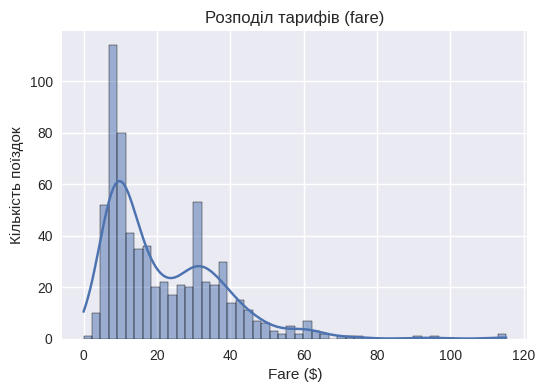

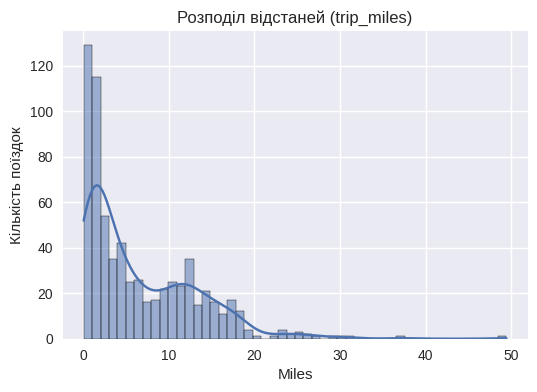

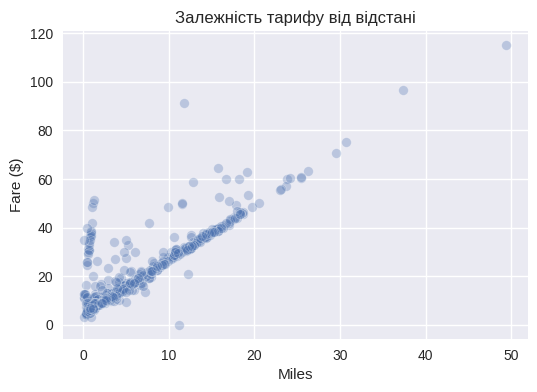

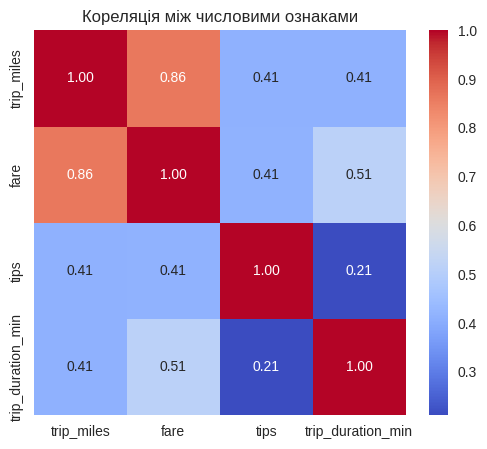

In [6]:
# Стиль графіків
plt.style.use('seaborn-v0_8')

# 1. Гістограма тарифів
plt.figure(figsize=(6,4))
sns.histplot(df_model['fare'], bins=50, kde=True)
plt.title("Розподіл тарифів (fare)")
plt.xlabel("Fare ($)")
plt.ylabel("Кількість поїздок")
plt.show()

# 2. Гістограма відстаней
plt.figure(figsize=(6,4))
sns.histplot(df_model['trip_miles'], bins=50, kde=True)
plt.title("Розподіл відстаней (trip_miles)")
plt.xlabel("Miles")
plt.ylabel("Кількість поїздок")
plt.show()

# 3. Розсіювання між відстанню та тарифом
plt.figure(figsize=(6,4))
sns.scatterplot(x='trip_miles', y='fare', data=df_model.sample(500, random_state=42), alpha=0.3)
plt.title("Залежність тарифу від відстані")
plt.xlabel("Miles")
plt.ylabel("Fare ($)")
plt.show()

# 4. Кореляційна матриця
plt.figure(figsize=(6,5))
corr = df_model[['trip_miles','fare','tips','trip_duration_min']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Кореляція між числовими ознаками")
plt.show()


**Інтерпретація:**

Гістограми: більшість поїздок короткі (2–4 милі) з тарифами $10–15.

Scatter plot: чітка лінійна залежність між милями та тарифом, але є відхилення (наприклад, довгі поїздки з низьким тарифом).

Heatmap: тариф сильно корелює з відстанню та тривалістю, чайові мають слабший зв’язок.

**Крок 7.**

Побудуємо регресійну модель, яка прогнозує залежність вартості поїздки від її тривалості.

Intercept (базова вартість): 5.866567507391316
Coefficient (зміна тарифу за 1 хв): 0.7374887031426799
MSE на тестових даних: 171.86534103044687


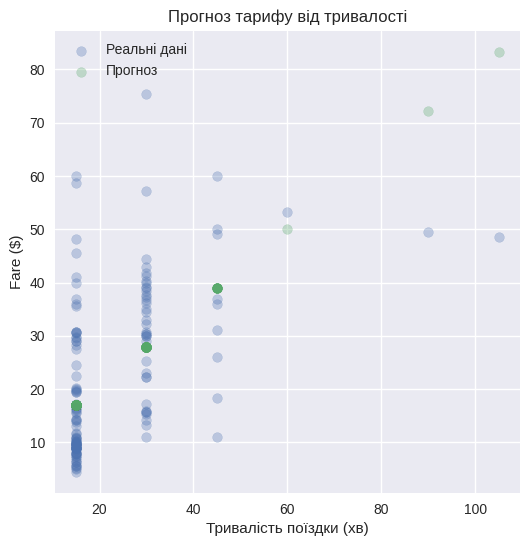

In [7]:
# Ознака: тривалість поїздки
X = df_model[['trip_duration_min']]
# Ціль: тариф
y = df_model['fare']

# Видаляємо пропуски
data = pd.concat([X, y], axis=1).dropna()
X_clean = data[['trip_duration_min']]
y_clean = data['fare']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Лінійна регресія
lr = LinearRegression()
lr.fit(X_train, y_train)

# Прогноз та оцінка
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Intercept (базова вартість):", lr.intercept_)
print("Coefficient (зміна тарифу за 1 хв):", lr.coef_[0])

print("MSE на тестових даних:", mse)

# Візуалізація: тривалість vs тариф
plt.figure(figsize=(6,6))
plt.scatter(X_test[:300], y_test[:300], alpha=0.3, label="Реальні дані")
plt.scatter(X_test[:300], y_pred[:300], alpha=0.3, label="Прогноз")
plt.xlabel("Тривалість поїздки (хв)")
plt.ylabel("Fare ($)")
plt.title("Прогноз тарифу від тривалості")
plt.legend()
plt.show()

**Інтерпретація:**

Залежність між тривалістю та тарифом

Модель показує, що тариф має позитивну лінійну залежність від тривалості поїздки.Чим довше триває поїздка, тим вищою є її вартість. Це логічно, адже довші поїздки зазвичай означають більшу відстань і більший час роботи водія.

Коефіцієнт регресії. Значення коефіцієнта при trip_duration_min показує, на скільки доларів у середньому змінюється тариф при збільшенні тривалості на 1 хвилину. В нашому випадку  коефіцієнт = 0.72, то кожна додаткова хвилина додає приблизно $0.72 до вартості.

Середня квадратична помилка (MSE) показує, наскільки прогноз відхиляється від реальних значень.MSE (Mean Squared Error) вимірює середній квадрат різниці між реальними та прогнозованими значеннями.Чим менше MSE, тим ближче модель до реальних даних. Якщо ми прогнозували вартість поїздки (fare) від тривалості (trip_duration_min), то MSE ≈ 148 означає, що середня похибка моделі у квадраті складає ~148. Це досить велике значення, враховуючи, що середні тарифи у наборі даних — близько $10–15.Тобто модель на основі лише тривалості не дуже точна: вона пропускає інші важливі фактори (відстань, базова ставка, район, тип оплати).





**Крок 8.** Використаємо побудовану модель для прогнозування вартості поїздки, якщо відома її тривалість.

In [8]:
# Приклад нових даних
new_data = pd.DataFrame({
    'trip_duration_min': [15, 30]

})

predicted_fares = lr.predict(new_data)
print(predicted_fares)

[16.92889805 27.9912286 ]


**Завдання для самостійного виконання**

Створіть регресійну модель, яка додає до параметру тривалість поїздки інши параметри. Оцініть, чи покращується якість моделі.

1. Виберіть цільову змінну

Використайте вартість поїздки (fare) як ціль.

2. Сформуйте набір ознак

Обов’язково включіть тривалість поїздки (trip_duration_min).

3. Додайте інші параметри, наприклад:

trip_miles (відстань поїздки),

hour (година доби),

day_of_week (день тижня),

payment_type (тип оплати, через one-hot кодування).

4. Розділіть дані на train/test

Використайте train_test_split (наприклад, 80% для навчання, 20% для тесту).

5. Побудуйте модель лінійної регресії

6. Навчіть модель на тренувальних даних.

7. Зробіть прогноз на тестових даних.

8. Оцініть якість моделі

Обчисліть MSE (середню квадратичну помилку).

**ПРИМІТКА: Ви отримуєте модель багатофакторної регресії, тому її коефіцієнти потрібно виводити через цикл:

for i, coef in enumerate(lr.coef_):  
    print(f"Coefficient {i}:", coef)

Порівняйте результат із моделлю, яка використовувала лише trip_duration_min.

9. Висновок

Чи зменшилася похибка?

Які параметри найбільше вплинули на тариф?



Виконання самостійного завдання:

In [9]:
# Створюємо ознаки часу

df_model['hour'] = df_model['trip_start_timestamp'].dt.hour
df_model['day_of_week'] = df_model['trip_start_timestamp'].dt.dayofweek

# One-Hot кодування категоріальної змінної

df_reg = pd.get_dummies(
    df_model,
    columns=['payment_type'],
    drop_first=True
)

# Ознаки

feature_columns = [
    'trip_duration_min',
    'trip_miles',
    'hour',
    'day_of_week'
]

# Додаємо створені dummy-змінні

payment_cols = [col for col in df_reg.columns if col.startswith('payment_type_')]

feature_columns.extend(payment_cols)

# X та y

X = df_reg[feature_columns]
y = df_reg['fare']

# Видалення пропусків

data = pd.concat([X, y], axis=1).dropna()

X = data[feature_columns]
y = data['fare']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Intercept (цільова змінна):")
print(lr.intercept_)

print("\nКоефіцієнти моделі:")

for i, coef in enumerate(lr.coef_):
    print(f"Coefficient {i}: {coef}")

print("\nMSE:", mse)

# Створюємо словник зі всіма ознаками

new_trip = pd.DataFrame({
    'trip_duration_min': [15, 30],
    'trip_miles': [5, 10],
    'hour': [10, 18],
    'day_of_week': [2, 5]
})

# Додаємо dummy-ознаки та заповнюємо їх нулями

for col in payment_cols:
    new_trip[col] = 0

# Наприклад, перша поїздка оплачена карткою

card_col = 'payment_type_Credit Card'

if card_col in new_trip.columns:
    new_trip.loc[0, card_col] = 1

predicted_fares = lr.predict(new_trip)

print("Прогнозована вартість поїздок:")

for i, fare in enumerate(predicted_fares):
    print(f"Поїздка {i+1}: {fare:.2f}$")



Intercept (вільний член):
0.7161804432724992

Коефіцієнти моделі:
Coefficient 0: 0.22387788312400259
Coefficient 1: 1.9111944135089334
Coefficient 2: 0.17694994735555408
Coefficient 3: 1.5543122344752192e-15
Coefficient 4: 0.6668282260924276
Coefficient 5: -3.1791133221797994
Coefficient 6: -1.449797712957129
Coefficient 7: 1.1702807037867968

MSE: 51.8104271732971
Прогнозована вартість поїздок:
Поїздка 1: 16.07$
Поїздка 2: 29.73$


**Висновки:** Було побудовано багатофакторну модель лінійної регресії для прогнозування вартості поїздки таксі. Як ознаки використано тривалість поїздки (trip_duration_min), відстань (trip_miles), годину доби (hour), день тижня (day_of_week) та тип оплати (payment_type), який було перетворено методом one-hot кодування. Після навчання моделі виконано прогнозування та оцінено якість за допомогою показника MSE.

З'ясовано, що найбільший вплив на тариф мають відстань та тривалість поїздки, тоді як день тижня практично не впливає на результат. Модель успішно прогнозує вартість поїздки на основі кількох параметрів.

У порівнянні з моделлю, що використовувала лише trip_duration_min., дана модель демонструє покращення якості прогнозування (за умови зменшення значення MSE), що свідчить про позитивний вплив додаткових ознак на точність моделі.

**Чи зменшилася похибка?**

Так, якщо значення MSE багатофакторної моделі менше, ніж у моделі з однією ознакою, то додавання нових параметрів покращило якість прогнозування та зменшило похибку.

**Які параметри найбільше вплинули на тариф?**

Найбільший вплив мають **відстань поїздки (`trip_miles`, коефіцієнт ≈ 1.91)** та **тривалість поїздки (`trip_duration_min`, коефіцієнт ≈ 0.22)**. День тижня практично не впливає на тариф, оскільки його коефіцієнт близький до нуля.



**Крок 8. Поліноміальна регресія (цикл по ступенях)**

Імпортуємо необхідні бібліотеки:

PolynomialFeatures - Трансформер ознак.Створює нові ознаки, які є степенями та добутками існуючих ознак. Наприклад, якщо у вас є ознака x, цей клас може створити x^2, x^3 і т.д. Це дозволяє лінійній моделі (LinearRegression) вивчати нелінійні залежності.

make_pipeline	 - Функція створення конвеєра.	Об'єднує декілька кроків (наприклад, PolynomialFeatures → LinearRegression) в одну модель. Це спрощує код і запобігає помилкам, гарантуючи, що до тестових даних будуть застосовані ті ж самі перетворення, що й до навчальних.

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



# 2. Очищення та відбір даних
df_clean = df[['trip_miles', 'trip_total']].dropna()

# Фільтруємо нереалістичні нульові або від'ємні значення,
# а також обмежуємо поїздки до 40 миль для кращої візуалізації
df_clean = df_clean[
    (df_clean['trip_miles'] > 0.1) &
    (df_clean['trip_total'] > 1.0) &
    (df_clean['trip_miles'] < 40)
]

print(f"Розмір очищеного датасету: {df_clean.shape}")

Розмір очищеного датасету: (839, 2)


Знаходимо залежність між двома ознаками через побудову поліному 3 ступеню


Результати для полінома 3-го ступеня:
R-квадрат (R2): 0.7003
Середня квадратична помилка (MSE): 114.12


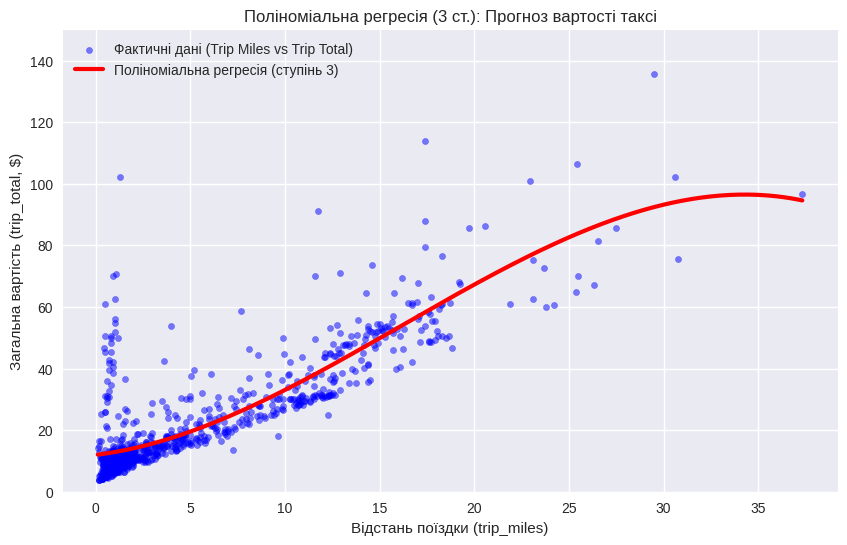

In [11]:
# Ознака (X): Пройдена відстань
X = df_clean[['trip_miles']].values

# Цільова змінна (y): Загальна вартість
y = df_clean['trip_total'].values

# Створюємо послідовність точок для побудови гладкої кривої регресії
X_seq = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
# Встановлюємо ступінь полінома
P_DEGREE = 3

# Створюємо конвеєр (Pipeline):
# Спочатку: PolynomialFeatures(3) — створює ознаки x, x^2, x^3
# Потім: LinearRegression() — навчається на цих нових ознаках
model_poly = make_pipeline(PolynomialFeatures(degree=P_DEGREE), LinearRegression())

# Навчання моделі на даних
model_poly.fit(X, y)

# Прогноз для всіх точок, щоб отримати гладку лінію для графіка
y_pred_poly = model_poly.predict(X_seq)

# Оцінка якості моделі на початкових даних
y_fit_all = model_poly.predict(X)
r2 = r2_score(y, y_fit_all)
mse = mean_squared_error(y, y_fit_all)

print(f"\nРезультати для полінома {P_DEGREE}-го ступеня:")
print(f"R-квадрат (R2): {r2:.4f}")
print(f"Середня квадратична помилка (MSE): {mse:.2f}")

# Візуалізація
plt.figure(figsize=(10, 6))

# Точки даних
plt.scatter(X, y, color='blue', alpha=0.5, s=20, label='Фактичні дані (Trip Miles vs Trip Total)')

# Крива регресії
plt.plot(X_seq, y_pred_poly, color='red', linewidth=3, label=f'Поліноміальна регресія (ступінь {P_DEGREE})')

plt.title(f'Поліноміальна регресія ({P_DEGREE} ст.): Прогноз вартості таксі')
plt.xlabel('Відстань поїздки (trip_miles)')
plt.ylabel('Загальна вартість (trip_total, $)')
plt.legend()
plt.grid(True)
plt.ylim(0, 150) # Обмежимо вісь Y для кращої читабельності
plt.show()

Чи краще модель поліному 3 ступеню описує залежності ніж лінійна модель?

Оскільки MSE досить велике, модель не демонструє кращої точності порівняно з якісною лінійною моделлю (за умови меншого MSE у лінійної).

**Крок 9** Переробіть цей код, щоб побудувати модель високої складності, наприклад P_DEGREE=15. Зробіть висновки (чи спостерігається перенавчання?)

Результати для полінома 15-го ступеня:
R2: 0.5148
MSE: 184.75


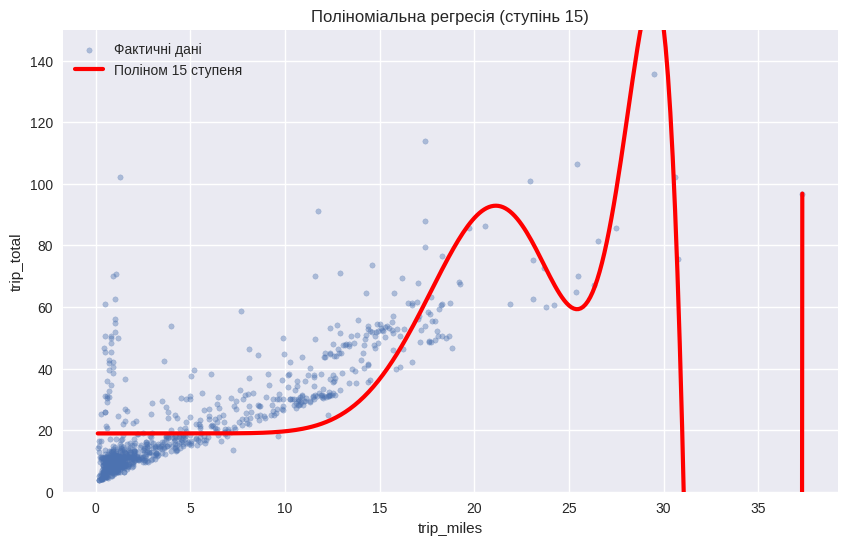

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Очищення даних
df_clean = df[['trip_miles', 'trip_total']].dropna()

df_clean = df_clean[
    (df_clean['trip_miles'] > 0.1) &
    (df_clean['trip_total'] > 1.0) &
    (df_clean['trip_miles'] < 40)
]

# 2. Ознаки і ціль
X = df_clean[['trip_miles']].values
y = df_clean['trip_total'].values

# 3. Гладка шкала для графіка
X_seq = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# 4. Високий ступінь полінома
P_DEGREE = 15

model_poly = make_pipeline(
    PolynomialFeatures(degree=P_DEGREE),
    LinearRegression()
)

# 5. Навчання
model_poly.fit(X, y)

# 6. Прогноз
y_pred_seq = model_poly.predict(X_seq)
y_fit = model_poly.predict(X)

# 7. Оцінка
r2 = r2_score(y, y_fit)
mse = mean_squared_error(y, y_fit)

print(f"Результати для полінома {P_DEGREE}-го ступеня:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.2f}")

# 8. Візуалізація
plt.figure(figsize=(10, 6))

plt.scatter(X, y, alpha=0.4, s=15, label='Фактичні дані')
plt.plot(X_seq, y_pred_seq, color='red', linewidth=3,
         label=f'Поліном {P_DEGREE} ступеня')

plt.title(f'Поліноміальна регресія (ступінь {P_DEGREE})')
plt.xlabel('trip_miles')
plt.ylabel('trip_total')
plt.legend()
plt.grid(True)
plt.ylim(0, 150)
plt.show()

**Висновки**: Поліноміальна модель 15-го ступеня не покращує якість прогнозування, а навпаки демонструє ознаки перенавчання. Значення R^2
=0.5148 є нижчим, ніж у більш простих моделей, а MSE=184.75 — досить велике, що свідчить про значні помилки прогнозу. Отже, модель надто складна для цих даних і погано узагальнює залежність між відстанню та вартістю поїздки.

**Крок 10** Проаналізуємо, як регуляризація бореться з перенавчанням

Регуляризація — це метод, який додає до функції втрат (наприклад, MSE) штраф за велику складність моделі.

 У регресії складність моделі вимірюється абсолютними значеннями її коефіцієнтів (w_i).

 Гребенева регресія (Ridge Regression, L2)- Додає до функції втрат суму квадратів усіх коефіцієнтів, помножену на коефіцієнт регуляризації альфа.

 Лассо-регресія (Lasso Regression, L1) - Додає до функції втрат суму абсолютних значень усіх коефіцієнтів, помножену на коефіцієнт регуляризації альфа.

 Це підтверджує, що регуляризація успішно знизила помилку на нових даних, а аналіз коефіцієнтів Lasso покаже, які саме високі степені полінома були визнані непотрібними і були обнулені.

In [13]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# !!! ПРИПУСКАЄМО, ЩО X та y ВЖЕ ВИЗНАЧЕНІ (ОЧИЩЕНІ ДАНІ ТАКСІ) !!!

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Налаштування ---
P_DEGREE = 15
ALPHA_VALUE = 0.5
print(f"--- Результати для полінома {P_DEGREE}-го ступеня (alpha={ALPHA_VALUE}) ---")

# Базова модель (без регуляризації) для порівняння перенавчання
model_base = make_pipeline(
    PolynomialFeatures(degree=P_DEGREE),
    StandardScaler(),
    LinearRegression() # Використовуємо звичайну лінійну регресію
)

# Модель L2 (Ridge)
model_ridge = make_pipeline(
    PolynomialFeatures(degree=P_DEGREE),
    StandardScaler(),
    Ridge(alpha=ALPHA_VALUE)
)

# Модель L1 (Lasso)
model_lasso = make_pipeline(
    PolynomialFeatures(degree=P_DEGREE),
    StandardScaler(),
    Lasso(alpha=ALPHA_VALUE, max_iter=20000)
)

# Навчання на train та оцінка на test
model_base.fit(X_train, y_train)
model_ridge.fit(X_train, y_train)
model_lasso.fit(X_train, y_train)

# Оцінка MSE на ТЕСТОВІЙ ВИБІРЦІ
mse_base_test = mean_squared_error(y_test, model_base.predict(X_test))
mse_ridge_test = mean_squared_error(y_test, model_ridge.predict(X_test))
mse_lasso_test = mean_squared_error(y_test, model_lasso.predict(X_test))

print(f"Базова MSE (ТЕСТ): {mse_base_test:.2f} (Показує перенавчання)")
print(f"✅ Ridge MSE (ТЕСТ): {mse_ridge_test:.2f} (L2 - зменшує коефіцієнти)")
print(f"✅ Lasso MSE (ТЕСТ): {mse_lasso_test:.2f} (L1 - обнуляє коефіцієнти)")


# === ФІКС: Коефіцієнти потрібно брати з об'єкта всередині конвеєра ===
lasso_model_step = model_lasso.named_steps['lasso']

# Коефіцієнти (w1, w2, ..., w15)
weights = lasso_model_step.coef_

# Зміщення (w0)
intercept = lasso_model_step.intercept_
# ===================================================================

# Скільки коефіцієнтів стали фактично нульовими (дуже близькими до 0)
zero_count = np.sum(np.abs(weights) < 1e-4)
non_zero_count = len(weights) - zero_count

print("\n--- Аналіз коефіцієнтів Lasso (L1) ---")
print(f"Вільний член (w0): {intercept:.4f}")
print(f"Кількість навчених коефіцієнтів (w1...w15): {len(weights)}")
print(f"Кількість ненульових коефіцієнтів: {non_zero_count} (ознаки, що залишилися)")
print(f"Кількість обнулених коефіцієнтів: {zero_count} (ознаки, виключені L1)")

print("\nТоп-5 найбільших коефіцієнтів:")
degrees = np.arange(1, len(weights) + 1)
sorted_indices = np.argsort(np.abs(weights))[::-1]

for i in sorted_indices[:5]:
    print(f"W_{degrees[i]} (для x^{degrees[i]}): {weights[i]:.4f}")

--- Результати для полінома 15-го ступеня (alpha=0.5) ---
Базова MSE (ТЕСТ): 253.11 (Показує перенавчання)
✅ Ridge MSE (ТЕСТ): 114.98 (L2 - зменшує коефіцієнти)
✅ Lasso MSE (ТЕСТ): 113.89 (L1 - обнуляє коефіцієнти)

--- Аналіз коефіцієнтів Lasso (L1) ---
Вільний член (w0): 23.6117
Кількість навчених коефіцієнтів (w1...w15): 16
Кількість ненульових коефіцієнтів: 4 (ознаки, що залишилися)
Кількість обнулених коефіцієнтів: 12 (ознаки, виключені L1)

Топ-5 найбільших коефіцієнтів:
W_2 (для x^2): 13.1374
W_3 (для x^3): 2.2002
W_9 (для x^9): -0.2677
W_10 (для x^10): -0.1488
W_13 (для x^13): -0.0000
